# Learning Unit 4 - Bias

## Reading Part - Prepare for exercise

**✏️ Task 4.1**

1. *Download "A Survey on Bias and Fairness in Machine Learning" https://dl.acm.org/doi/10.1145/3457607. (You can download it per Eduroam or VPN if your are working from home.)*
2. *You do NOT have to read it, but you need to have the paper for the exercise.*

---

## Programming Part - Get to know datasets

In this learning unit, we will explore the diabetes dataset you already worked with in previous learning units.

The dataset is called *“CDC Diabetes Health Indicators”*. You can find more information about it in the UCI ML Library [here](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators). In the Resources section, we have also provided a file called `diabetes_012_health_indicators_BRFSS2015.csv`, which is one of three csv files in the dataset.

In this learning unit, we will continue our analysis of the *CDC Diabetes Health Indicators* dataset. We will investigate the possible biases of this dataset, and we will train a diabetes prediction model.

First, let's take loot another at the attributes of our dataset. In the last learning unit, we examined the distributions of the attributes and their meanings. This time, we want to take a closer look at the potential problems that can arise from including certain features.

**✏️ Task 4.2** 
*Perform an exploratory data analysis on the dataset. Think about all the things that you would need to know about this data in order to make confident statements about it and to be able to continue to work with it. Make sure to at least:*
- *look at the features and try to understand them,*
- *look at the distributions of the following features: sex, age education, income, diabetes_012, HighBP, HighChol*

*Write down your code in the Python cell, and your key findings about the sample in the Markdown cell below.*

If you are feeling lost about the exploratory data analysis, take a look at the linked article in the resources section below.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [4]:
target_cols = ['Sex', 'Age', 'Education', 'Income', 'Diabetes_012', 'HighBP', 'HighChol']
df[target_cols]

,Sex,Age,Education,Income,Diabetes_012,HighBP,HighChol
0,0.0,9.0,4.0,3.0,0.0,1.0,1.0
1,0.0,7.0,6.0,1.0,0.0,0.0,0.0
2,0.0,9.0,4.0,8.0,0.0,1.0,1.0
3,0.0,11.0,3.0,6.0,0.0,1.0,0.0
4,0.0,11.0,5.0,4.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...
253675,1.0,5.0,6.0,7.0,0.0,1.0,1.0
253676,0.0,11.0,2.0,4.0,2.0,1.0,1.0
253677,0.0,2.0,5.0,2.0,0.0,0.0,0.0
253678,1.0,7.0,5.0,1.0,0.0,1.0,0.0


In [5]:
df[target_cols].describe()

,Sex,Age,Education,Income,Diabetes_012,HighBP,HighChol
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.440342,8.032119,5.050434,6.053875,0.296921,0.429001,0.424121
std,0.496429,3.054220,0.985774,2.071148,0.698160,0.494934,0.494210
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,6.000000,4.000000,5.000000,0.000000,0.000000,0.000000
50%,0.000000,8.000000,5.000000,7.000000,0.000000,0.000000,0.000000
75%,1.000000,10.000000,6.000000,8.000000,0.000000,1.000000,1.000000
max,1.000000,13.000000,6.000000,8.000000,2.000000,1.000000,1.000000


In [6]:
df[target_cols].isnull().sum()

Sex             0
Age             0
Education       0
Income          0
Diabetes_012    0
HighBP          0
HighChol        0
dtype: int64

In [7]:
for col in target_cols:
    print(df[col].value_counts(normalize=True).sort_index()*100)

Sex
0.0    55.965784
1.0    44.034216
Name: proportion, dtype: float64
Age
1.0      2.246925
2.0      2.995112
3.0      4.384658
4.0      5.448991
5.0      6.369048
6.0      7.812599
7.0     10.372911
8.0     12.153895
9.0     13.104699
10.0    12.690792
11.0     9.276648
12.0     6.299275
13.0     6.844450
Name: proportion, dtype: float64
Education
1.0     0.068590
2.0     1.593740
3.0     3.736203
4.0    24.735888
5.0    27.558341
6.0    42.307237
Name: proportion, dtype: float64
Income
1.0     3.867471
2.0     4.644828
3.0     6.304793
4.0     7.937165
5.0    10.203012
6.0    14.376380
7.0    17.036818
8.0    35.629533
Name: proportion, dtype: float64
Diabetes_012
0.0    84.241170
1.0     1.825528
2.0    13.933302
Name: proportion, dtype: float64
HighBP
0.0    57.09989
1.0    42.90011
Name: proportion, dtype: float64
HighChol
0.0    57.587906
1.0    42.412094
Name: proportion, dtype: float64


C:\Users\Work\AppData\Local\Temp\ipykernel_17392\3413308740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='summer')
C:\Users\Work\AppData\Local\Temp\ipykernel_17392\3413308740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='summer')
C:\Users\Work\AppData\Local\Temp\ipykernel_17392\3413308740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='summer')
C:\Users\Work\AppData\Local\Temp\ipykernel_17392\3413308740.py:5: F

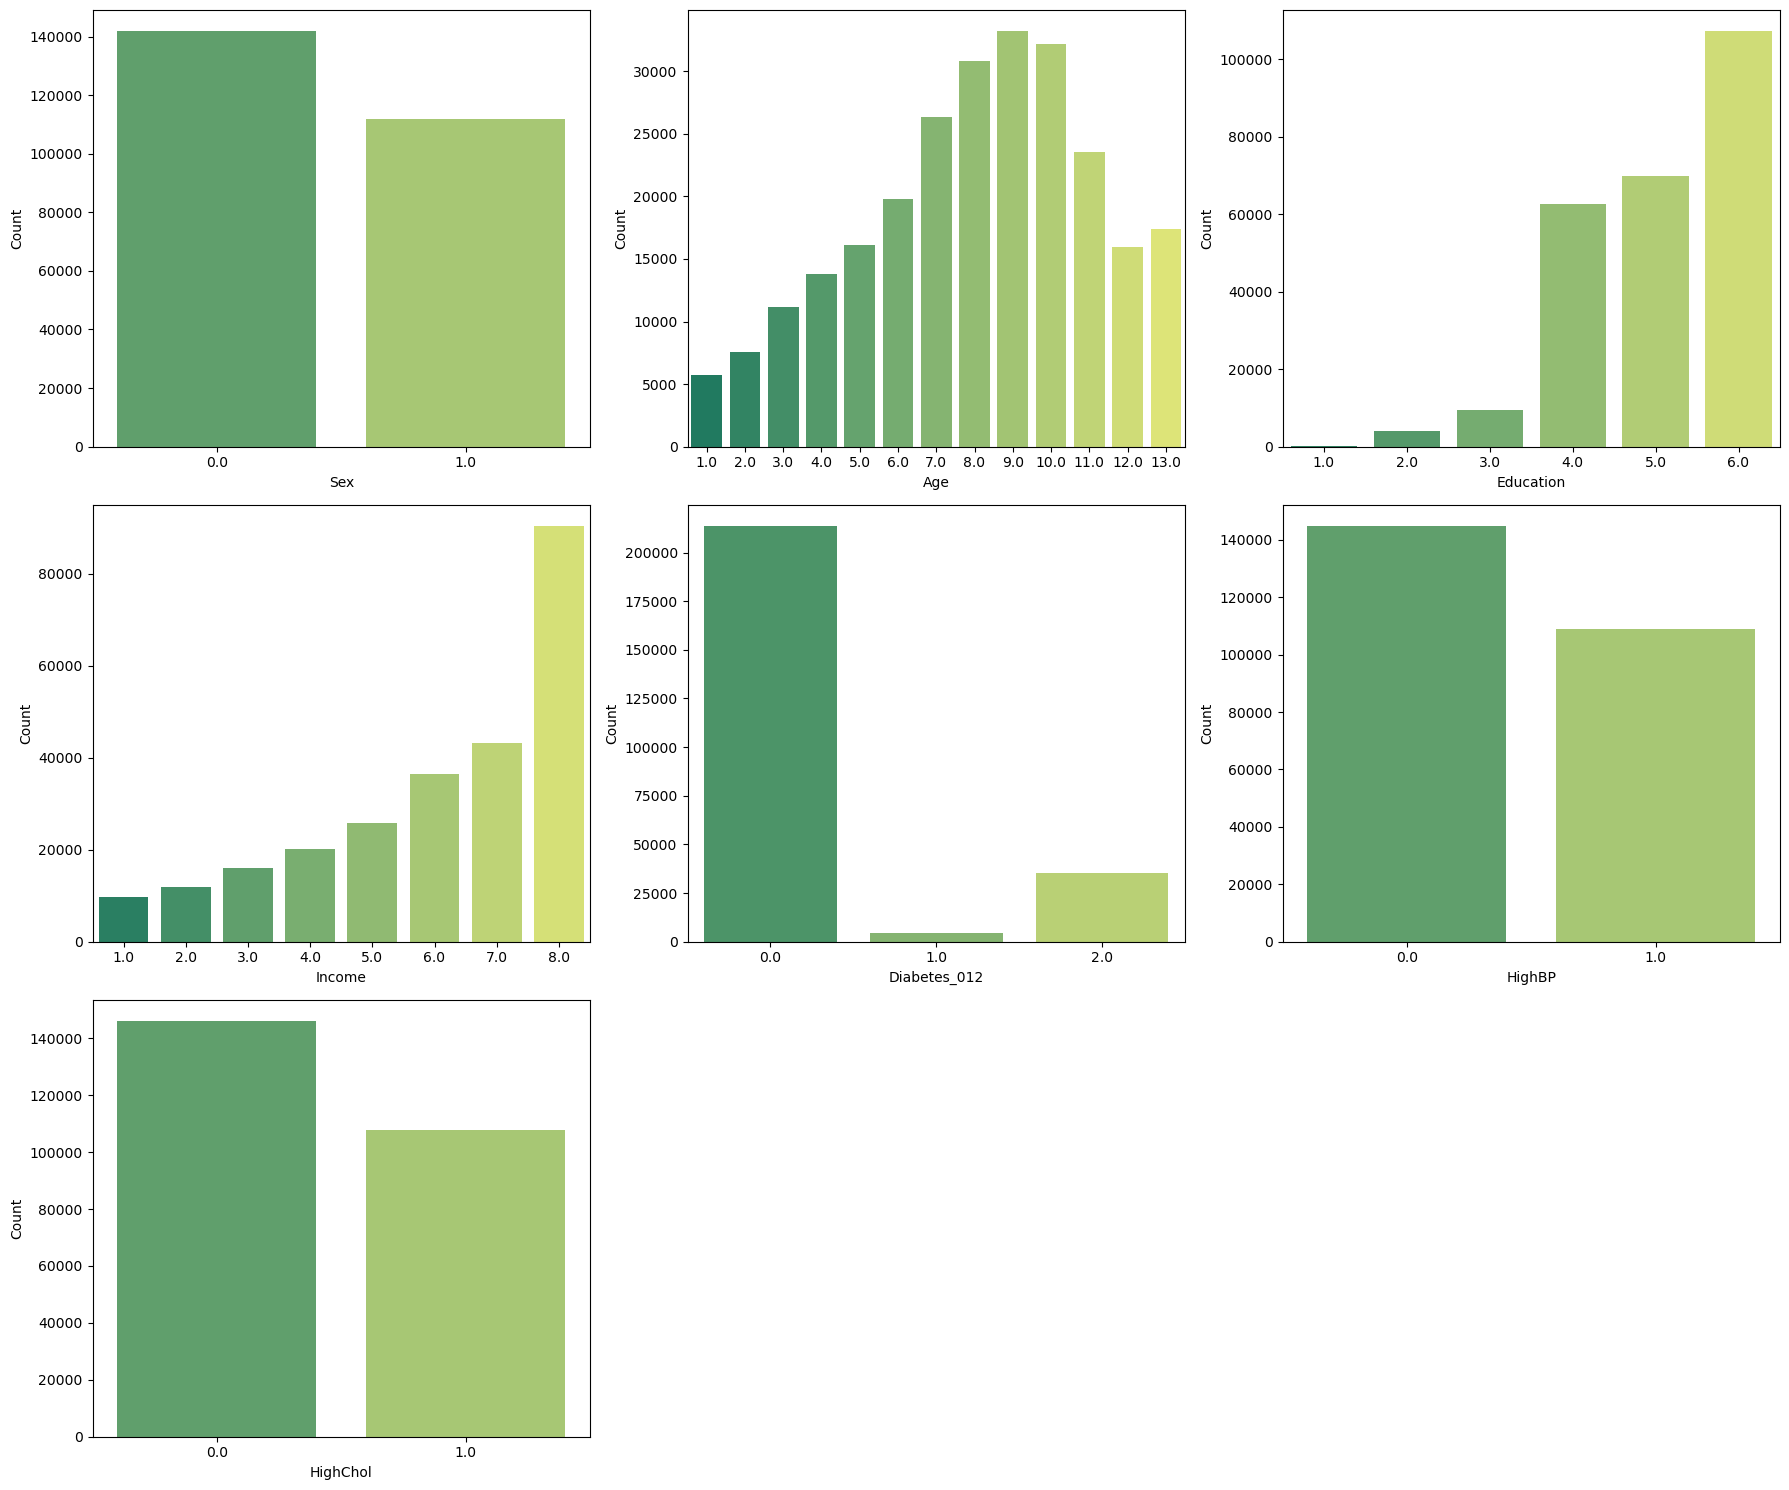

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,15))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='summer')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(len(target_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Key Findings
------------
Diabetes_012: The target variable is highly imbalanced. Around 84.2% of the participants do not have diabetes, while only 13.9% are diabetic and just 1.8% fall under pre-diabetes. This imbalance is important to consider during model training so the predictions do not become biased toward the majority class.

HighBP & HighChol: Around 42.9% of the sample reports having high blood pressure, while about 42.4% reports having high cholesterol.

Age: The dataset is skewed toward older individuals, with most of the respondents belonging to categories 7 through 11.

Education & Income: There’s a clear skew toward higher education levels, with about 42.3% in the highest category, and also toward higher income groups, with roughly 35.6% in the top bracket. This suggests the sample may not fully represent lower-income or less-educated populations.

---

In the lecture, you learned about *"protected attributes"*. Protected attributes refer to sensitive or personal characteristics that are legally or ethically protected from being used as a basis for discrimination in data science applications. The *CDC Diabetes Health Indicators* dataset contains some of these attributes. It is important to understand and be able to identify the difference between protected and unprotected attributes.

**✏️ Task 4.3**
1. *What are the protected attributes of the dataset?*
2. *Explain why it makes sense to protect these attributes. Identify any problems that may arise from including them.*
3. *Is using the unprotected attributes unproblematic?*

*Please write your answers in the markdown cell below.*

1. Sex is considered a core protected characteristic across any ethical frameworks. Age is also protected, especially in contexts like healthcare and employment where age-based discrimination is a concern. Income and education reflect socioeconomic status, while they are not always legally classified as protected in the same way as attributes like race or sex, they are still ethically sensitive because they can proxy for disadvantaged groups and potentially lead to class-based bias. DiffWalk can be interpreted as a proxy for disability, which is a protected characteristic in many cases.

2. Fairness and equity become a concern when these attributes influence decisions such as insurance pricing or healthcare prioritisation, since this can result in unequal treatment. There are legal considerations. In many regions, regulations such as the GDPR in Europe restrict or prohibit the use of sensitive personal data in automated decision-making systems that have a significant impact on individuals. If a model predicts that lower-income individuals are 'higher risk' , they might be charged more for insurance, making them even more financially vulnerable and less likely to afford care, thus worsening their health outcomes.

3. Using unprotected attributes is not necessarily free of problems. Some of these features can act as proxy variables for protected ones, since they are often correlated - for example, physical activity or fruit consumption may indirectly reflect income levels, which can still lead to indirect bias against lower-income groups. There is also structural bias to consider, as factors like smoking or BMI are shaped by broader social and economic conditions rather than purely individual choices. In addition, because the data is self-reported through surveys like BRFSS, it may suffer from heavy bias, where people overstate healthy habits and underreport unhealthy ones, affecting accuracy across different groups.

---

We continue to train a first version of a diabetes type prediction system. You will compare this system to the one you create in the next assignment to evaluate the impact of bias mitigation and fairness techniques. 

This task is intended to be open-ended. You are expected to use your prior data science knowledge. Think about the type of problem you are trying to solve and what model might be a good fit. If you are not sure what to do, take a look at Assignment 1 for a model training example and consider looking at other resources.

**✏️ Task 4.4** 
1. *Train a model that predicts the type of diabetes (the “diabetes_012” feature).*
2. *Try at least one other type of model and compare the results with the model from step 1 (e.g., RandomForestClassifier, KNeighborsClassifier, LogisticRegression).*
3. *Choose the best performing model and further optimize it. Try to avoid [common pitfalls](https://www.gyata.ai/machine-learning/machine-learning-optimization/) of machine learning optimization.* <br>
Hint: Save the model and your predictions, you will need them in the next learning unit again!

*Please write your answers in the markdown cell below.*

In [9]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [10]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

c:\Users\Work\miniconda3\envs\ds_311_hcds1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Logistic Regression Accuracy: 0.8457


In [13]:
# 2: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

c:\Users\Work\miniconda3\envs\ds_311_hcds1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [14]:
knn_acc = accuracy_score(y_test, knn_pred)
print(f"K-Neighbors Accuracy: {knn_acc:.4f}")

K-Neighbors Accuracy: 0.8311


Optimized Models

In [15]:
lr_optim = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced', random_state=42)
lr_optim.fit(X_train, y_train)
lr_optim_pred = lr_optim.predict(X_test)

In [16]:
lr_optim_acc = accuracy_score(y_test, lr_optim_pred)
print(f"Logistic Regression optimized Accuracy: {lr_optim_acc:.4f}")

Logistic Regression optimized Accuracy: 0.6458


In [17]:
knn_optim = KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1)
knn_optim.fit(X_train, y_train)
knn_optim_pred = knn_optim.predict(X_test)

In [18]:
knn_optim_acc = accuracy_score(y_test, knn_optim_pred)
print(f"KNN optimized Accuracy: {knn_optim_acc:.4f}")

KNN optimized Accuracy: 0.8374


In [19]:
joblib.dump(knn_optim, 'diabetes_model.joblib')
final_preds = knn_optim.predict(X_test)
pd.DataFrame({'Actual': y_test, 'Predicted': final_preds}).to_csv('diabetes_predictions.csv', index=False)

---

## 📝 Feedback
We are interested in your feedback in order to improve this course. We will read all of your feedback and evaluate it. What you share may have a direct impact on the rest of the course or future iterations of it.

Write down your feedback on the lecture, the exercises, or the assignments in the Markdown cell below. Furthermore, please note the approximate time it took you to complete the assignment. You may also write about your insights, what you found interesting, or questions that you have.